# BW \#126 Electronic Vehicules Sales
How many EVs have really been sold over the last few years? Has the US seen an uptick in the number of EVs sold? Where are these EVs being sold?

## Data and six questions
This week's data comes from the US Department of Transportation's Bureau of Transportation Statistics.

## Challenges
The learning goals include working with Excel files, plotting with seaborn, multi indexes and window functions
- read the excel file into a pandas df using the first and second columns ("State" and the measurement category) as the 2 parts of a multiindex
- using seaborn, create a line plot showing the proportion of EV registrations in each year for which we have data (i.e. 2016-2023) over the entire US. Do we see an obvious trend ? 


## Read the excel file into a pandas df using the first and second columns ("State" and the measurement category) as the 2 parts of a multiindex


In [43]:
import pandas as pd

filename = r'C:\Users\npigeon1\Pandas-Bamboo-Weekly\BW #126 EVSales\Sheet 1.xlsx'
df = pd.read_excel(filename, index_col=[0,1])
df.head(30)

2016  \
State                                                                 
United States EV Electric Consumption (megawatt hours)          NaN   
              EV registrations                             280300.0   
              HEV registrations                           3741600.0   
              PHEV registrations                           254000.0   
              Gas Vehicle Registrations                 224855100.0   
              Diesel Vehicle Registrations                7734000.0   
              Total Vehicle Registrations               268799083.0   
Alabama       EV Electric Consumption (megawatt hours)          NaN   
              EV registrations                                500.0   
              HEV registrations                             29100.0   
              PHEV registrations                              900.0   
              Gas Vehicle Registrations                   3777300.0   
              Diesel Vehicle Registrations                 126500.0   
              Total Vehicle Registrations                 5468301.0   
Alaska        EV Electric Consumption (megawatt hours)          NaN   
              EV registrations                                200.0   
              HEV registrations                              5000.0   
              PHEV registrations                              200.0   
              Gas Vehicle Registrations                    525900.0   
              Diesel Vehicle Registrations                  44800.0   
              Total Vehicle Registrations                  794614.0   
Arizona       EV Electric Consumption (megawatt hours)          NaN   
              EV registrations                               4700.0   
              HEV registrations                             89600.0   
              PHEV registrations                             4400.0   
              Gas Vehicle Registrations                   4805000.0   
              Diesel Vehicle Registrations                 179500.0   
              Total Vehicle Registrations                 5786891.0   
Arkansas      EV Electric Consumption (megawatt hours)          NaN   
              EV registrations                                200.0   

                                                               2017  \
State                                                                 
United States EV Electric Consumption (megawatt hours)          NaN   
              EV registrations                             377100.0   
              HEV registrations                           4036000.0   
              PHEV registrations                           344600.0   
              Gas Vehicle Registrations                 227415700.0   
              Diesel Vehicle Registrations                8115800.0   
              Total Vehicle Registrations               272480899.0   
Alabama       EV Electric Consumption (megawatt hours)          NaN   
              EV registrations                                800.0   
              HEV registrations                             30600.0   
              PHEV registrations                             1100.0   
              Gas Vehicle Registrations                   3750700.0   
              Diesel Vehicle Registrations                 131500.0   
              Total Vehicle Registrations                 5056073.0   
Alaska        EV Electric Consumption (megawatt hours)          NaN   
              EV registrations                                400.0   
              HEV registrations                              5200.0   
              PHEV registrations                              300.0   
              Gas Vehicle Registrations                    506800.0   
              Diesel Vehicle Registrations                  43200.0   
              Total Vehicle Registrations                  804505.0   
Arizona       EV Electric Consumption (megawatt hours)          NaN   
              EV registrations                               7200.0   
              H

## Using seaborn, create a line plot showing the proportion of EV registrations in each year for which we have data (i.e. 2016-2023) over the entire US. Do we see an obvious trend ? 


In [48]:
(
    df
    .loc['United States'] #outter index 
    .drop(columns=['2024']) # drop the column 2024 because it has no data and else they are string and not integer
    .loc[['EV registrations', 'Total Vehicle Registrations']] # inner index 
    .T # transpose so we can easily divide the two rows to get the proportion of EV registrations
    .assign(Proportion=lambda df_: df_['EV registrations'] / df_['Total Vehicle Registrations']*100) # calculate the proportion

    )


,EV registrations,Total Vehicle Registrations,Proportion
2016,280300.0,268799083.0,0.104279
2017,377100.0,272480899.0,0.138395
2018,572600.0,273602100.0,0.209282
2019,783600.0,276491174.0,0.283409
2020,1018900.0,275924442.0,0.369268
2021,1454400.0,282366285.0,0.515076
2022,2442300.0,283400986.0,0.861782
2023,3555900.0,287096500.0,1.238573


I could invoke sns.lineplot and pass it my data frame. But if I want to use a method chain, I'm in a bit of trouble.

The solution is the pipe method, which allows us to take a function whose first argument is a series, and effectively invoke it as a method.

<Axes: xlabel='None'>

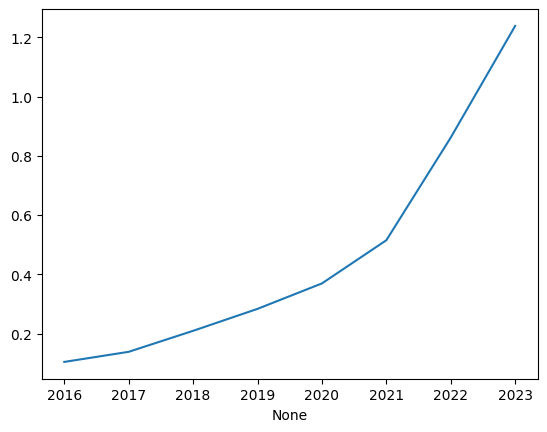

In [ ]:
import seaborn as sns 
(
    df
    .loc['United States']
    .drop(columns=['2024'])
    .loc[['EV registrations', 'Total Vehicle Registrations']]
    .T
    .assign(ev_pct = lambda df_: df_['EV registrations'] /
               df_['Total Vehicle Registrations'] * 100)
    ['ev_pct']
    .pipe(lambda s_: sns.lineplot(x=s_.index, 
                                      y=s_.values))    
)

We can definetly see upward spike in the popularity of EVs over the last number of years, and that number has accelerated in just the last 2-3 years. However even after this rapid increase, the YS is still at just 1.2 percent EVs